# The Greeks

Part 2 of the series. The Greeks characterise how an option's value responds to each input — the underlying price, volatility, time, and rates. In Black-Scholes form:

$$ \Theta = r(V - S\Delta) - \tfrac{1}{2}\sigma^2 S^2 \Gamma $$

i.e. time decay equals the interest earned on the cash-equivalent portfolio value, minus the curvature term. All analytical formulas below live in [`optionspricing.greeks`](../src/optionspricing/greeks.py); each has a numerical counterpart for a finite-difference cross-check, used at the end of this notebook.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from optionspricing import black_scholes_call, delta_call, gamma, vega, theta_call, rho_call
from optionspricing.greeks import (
    numerical_delta, numerical_gamma, numerical_vega, numerical_theta, numerical_rho,
)

S, K, T, r, sigma = 100, 100, 1, 0.05, 0.20
S_values = np.linspace(20, 180, 100)
tau_values = np.linspace(0.01, 2, 100)

### Delta, $\Delta = \partial V/\partial S$

How much the option moves per $1 move in the underlying. A long call's delta runs from 0 (deep OTM) to 1 (deep ITM).

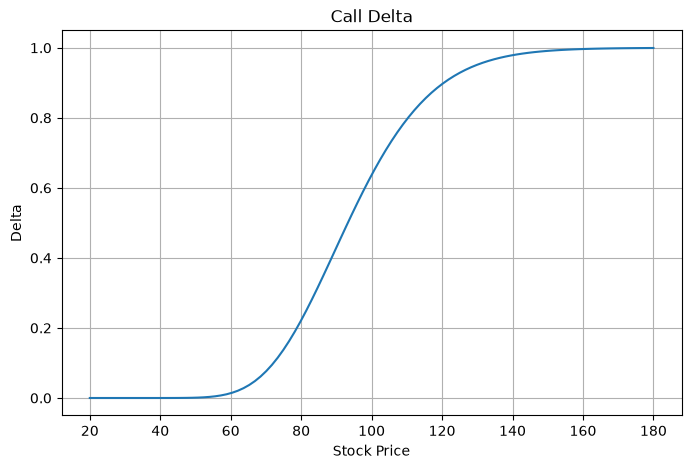

In [3]:
delta_values = [delta_call(s, K, T, r, sigma) for s in S_values]

plt.figure(figsize=(8, 5))
plt.plot(S_values, delta_values)
plt.xlabel('Stock Price'); plt.ylabel('Delta'); plt.title('Call Delta')
plt.grid(True); plt.show()

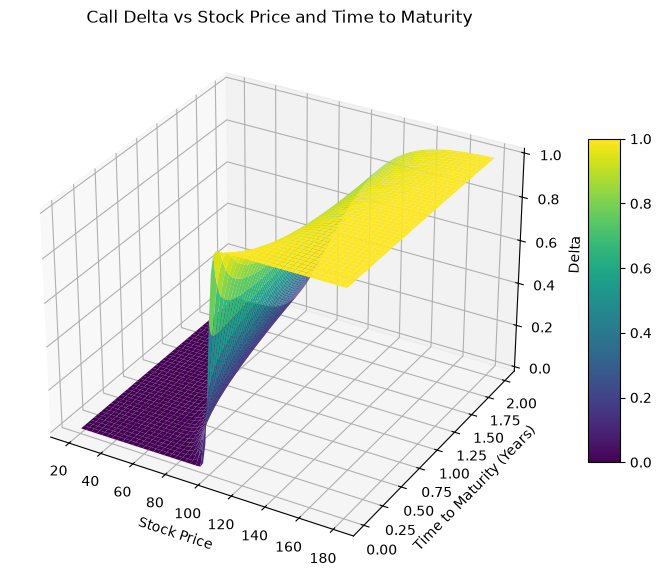

In [4]:
S_grid, tau_grid = np.meshgrid(S_values, tau_values)
delta_surface = np.zeros_like(S_grid)
for i in range(len(tau_values)):
    for j in range(len(S_values)):
        delta_surface[i, j] = delta_call(S_grid[i, j], K, tau_grid[i, j], r, sigma)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(S_grid, tau_grid, delta_surface, cmap='viridis', edgecolor='none')
ax.set_xlabel('Stock Price'); ax.set_ylabel('Time to Maturity (Years)'); ax.set_zlabel('Delta')
ax.set_title('Call Delta vs Stock Price and Time to Maturity')
fig.colorbar(surface, shrink=0.6, aspect=10)
plt.show()

As time to expiry shrinks, the transition from Delta ~ 0 to Delta ~ 1 becomes an extremely sharp step around S = K; longer-dated options give a more gradual curve.

### Gamma, $\Gamma = \partial^2 V/\partial S^2$

Rate of change of delta — the curvature of the price curve. Always positive for long options, and peaks at-the-money near expiry, where delta changes fastest.

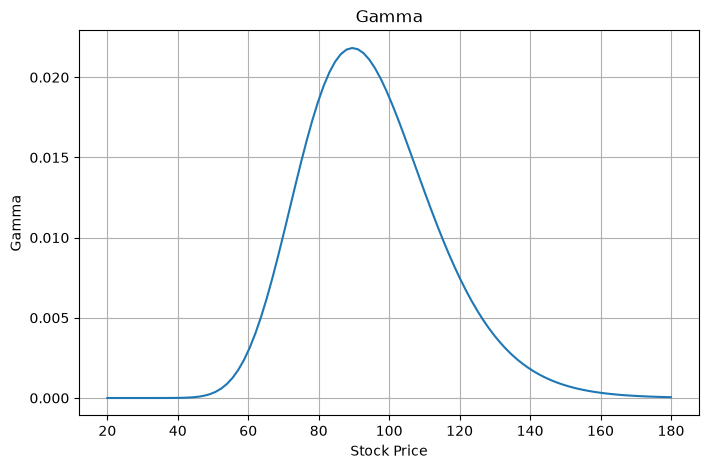

In [5]:
gamma_values = [gamma(s, K, T, r, sigma) for s in S_values]

plt.figure(figsize=(8, 5))
plt.plot(S_values, gamma_values)
plt.xlabel('Stock Price'); plt.ylabel('Gamma'); plt.title('Gamma')
plt.grid(True); plt.show()

Gamma peaks at-the-money. As time to expiry shrinks this curve narrows towards a delta function, consistent with delta's step-function behaviour near expiry.

### Vega, $\text{Vega} = \partial V/\partial \sigma$

Sensitivity to volatility (same sign for calls and puts). Long options always have positive vega.

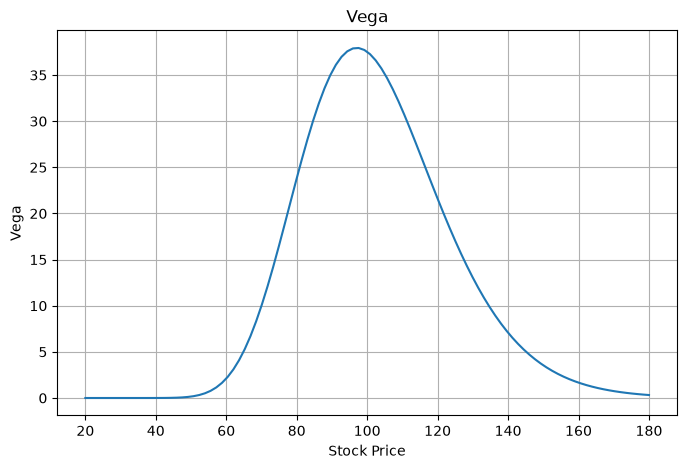

In [6]:
vega_values = [vega(s, K, T, r, sigma) for s in S_values]

plt.figure(figsize=(8, 5))
plt.plot(S_values, vega_values)
plt.xlabel('Stock Price'); plt.ylabel('Vega'); plt.title('Vega')
plt.grid(True); plt.show()

Vega peaks near the strike, where an option's fate is most sensitive to how volatile the underlying turns out to be.

### Theta, $\Theta = \partial V/\partial t$

Sensitivity to time passage. Long options almost always have negative theta — time works against buyers.

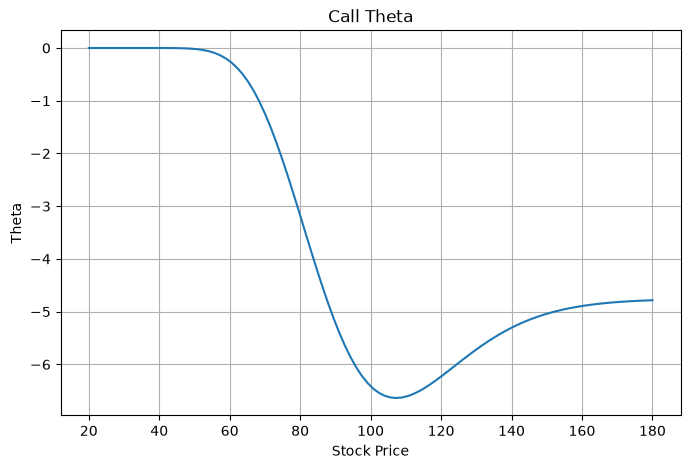

In [7]:
theta_values = [theta_call(s, K, T, r, sigma) for s in S_values]

plt.figure(figsize=(8, 5))
plt.plot(S_values, theta_values)
plt.xlabel('Stock Price'); plt.ylabel('Theta'); plt.title('Call Theta')
plt.grid(True); plt.show()

### Rho, $\rho = \partial V/\partial r$

Sensitivity to the risk-free rate. Positive for calls, negative for puts, since a higher rate raises the value of deferring payment of the strike.

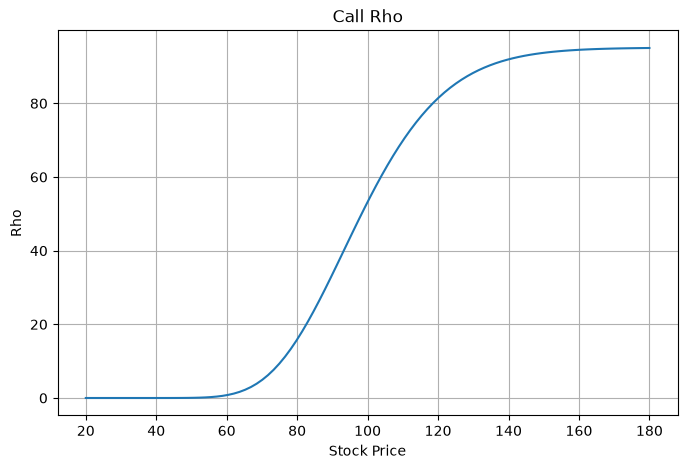

In [8]:
rho_values = [rho_call(s, K, T, r, sigma) for s in S_values]

plt.figure(figsize=(8, 5))
plt.plot(S_values, rho_values)
plt.xlabel('Stock Price'); plt.ylabel('Rho'); plt.title('Call Rho')
plt.grid(True); plt.show()

### Where this model breaks

- **Gamma spikes near expiry and ATM**: a gamma-hedged book still needs continuous re-hedging; discrete rebalancing leaves residual gamma risk.
- **Vega is model-dependent**: BS vega assumes flat vol. Real books hedge against the whole vol surface (vanna, volga) — BS vega alone is insufficient.
- **Theta/gamma duality**: for a delta-hedged position, daily P&L is approximately $\tfrac12\Gamma(\Delta S)^2 - \Theta\Delta t$. If realised vol exceeds implied vol you collect; if not, you pay. This is the core of volatility trading.

## Sensitivity analysis

How does the call price move when we vary one parameter at a time, holding the others fixed?

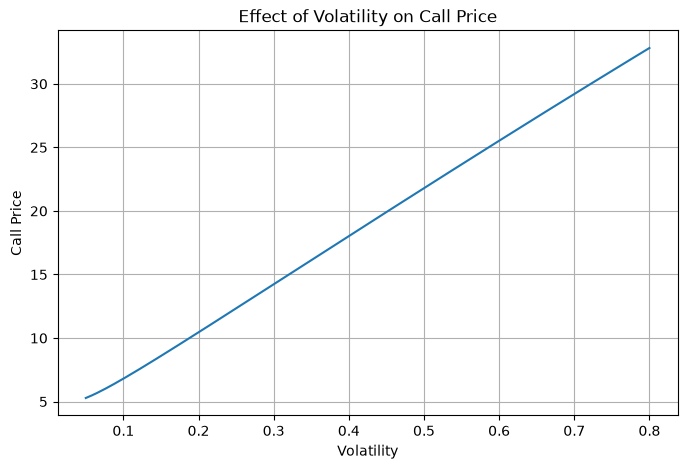

In [9]:
sigma_values = np.linspace(0.05, 0.80, 200)
call_vol = [black_scholes_call(S, K, T, r, s) for s in sigma_values]

plt.figure(figsize=(8, 5))
plt.plot(sigma_values, call_vol)
plt.xlabel('Volatility'); plt.ylabel('Call Price'); plt.title('Effect of Volatility on Call Price')
plt.grid(True); plt.show()

Higher volatility raises the probability of large favourable moves while the downside stays capped at the premium paid, so higher volatility always increases call value. Below is the full call-value surface against stock price and volatility, plus the vega surface that explains its shape.

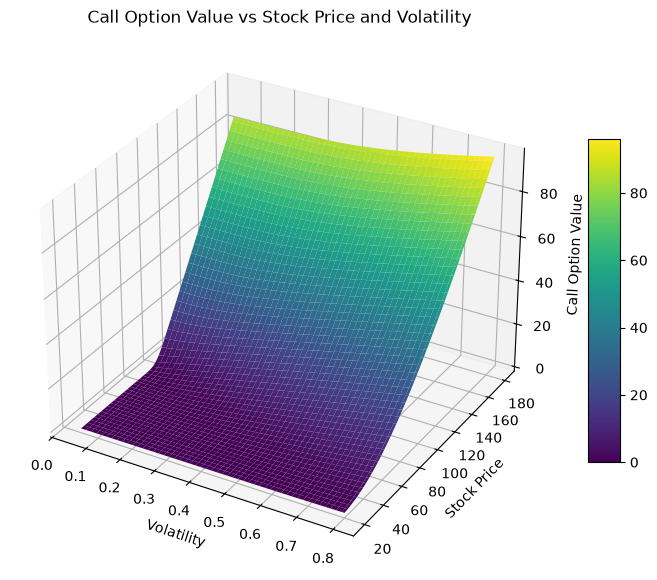

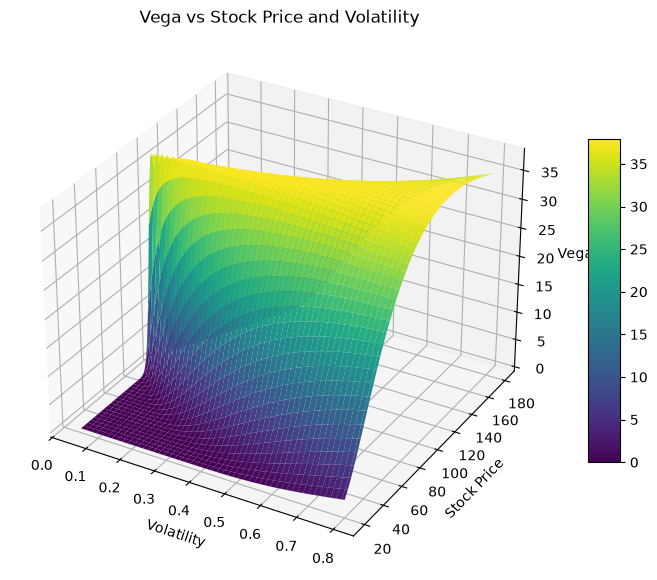

In [10]:
sigma_grid_vals = np.linspace(0.05, 0.80, 100)
S_grid, sigma_grid = np.meshgrid(S_values, sigma_grid_vals)

call_surface = np.zeros_like(S_grid)
vega_surface = np.zeros_like(S_grid)
for i in range(len(sigma_grid_vals)):
    for j in range(len(S_values)):
        call_surface[i, j] = black_scholes_call(S_grid[i, j], K, T, r, sigma_grid[i, j])
        vega_surface[i, j] = vega(S_grid[i, j], K, T, r, sigma_grid[i, j])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(sigma_grid, S_grid, call_surface, cmap='viridis', edgecolor='none')
ax.set_xlabel('Volatility'); ax.set_ylabel('Stock Price'); ax.set_zlabel('Call Option Value')
ax.set_title('Call Option Value vs Stock Price and Volatility')
fig.colorbar(surface, shrink=0.6, aspect=10)
plt.show()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(sigma_grid, S_grid, vega_surface, cmap='viridis', edgecolor='none')
ax.set_xlabel('Volatility'); ax.set_ylabel('Stock Price'); ax.set_zlabel('Vega')
ax.set_title('Vega vs Stock Price and Volatility')
fig.colorbar(surface, shrink=0.6, aspect=10)
plt.show()

The call-value surface is steepest around $S \approx K$, exactly where vega is largest. For very high stock prices, extra volatility barely matters since the option is already almost certainly finishing in the money.

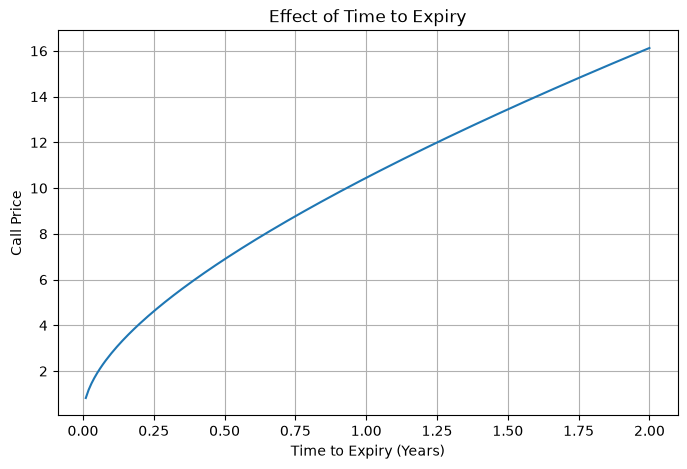

In [11]:
tau_range = np.linspace(0.01, 2, 200)
call_time = [black_scholes_call(S, K, tau, r, sigma) for tau in tau_range]

plt.figure(figsize=(8, 5))
plt.plot(tau_range, call_time)
plt.xlabel('Time to Expiry (Years)'); plt.ylabel('Call Price'); plt.title('Effect of Time to Expiry')
plt.grid(True); plt.show()

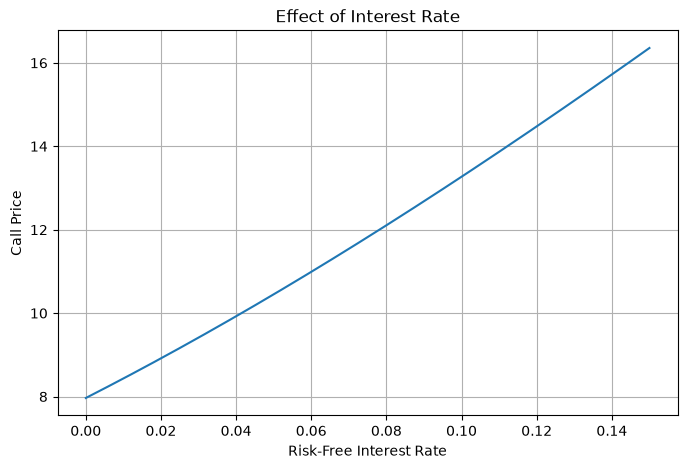

In [12]:
r_values = np.linspace(0, 0.15, 200)
call_rate = [black_scholes_call(S, K, T, rate, sigma) for rate in r_values]

plt.figure(figsize=(8, 5))
plt.plot(r_values, call_rate)
plt.xlabel('Risk-Free Interest Rate'); plt.ylabel('Call Price'); plt.title('Effect of Interest Rate')
plt.grid(True); plt.show()

Higher rates reduce the present value of the strike, $Ke^{-rT}$, which makes the call more valuable — the mirror image of rho's sign for puts.

## Numerical Greeks

Central finite differences give a second-order-accurate way to approximate the Greeks without an analytical derivative — useful for instruments where no closed form exists. We cross-check every analytical Greek above against its finite-difference counterpart.

In [13]:
print('Delta   analytical:', delta_call(S, K, T, r, sigma), ' numerical:', numerical_delta(S, K, T, r, sigma))
print('Gamma   analytical:', gamma(S, K, T, r, sigma), ' numerical:', numerical_gamma(S, K, T, r, sigma))
print('Vega    analytical:', vega(S, K, T, r, sigma), ' numerical:', numerical_vega(S, K, T, r, sigma))
print('Theta   analytical:', theta_call(S, K, T, r, sigma), ' numerical:', numerical_theta(S, K, T, r, sigma))
print('Rho     analytical:', rho_call(S, K, T, r, sigma), ' numerical:', numerical_rho(S, K, T, r, sigma))

Delta   analytical: 0.6368306511756191  numerical: 0.6368306425763137
Gamma   analytical: 0.018762017345846895  numerical: 0.018762017077733617
Vega    analytical: 37.52403469169379  numerical: 37.52400424279756
Theta   analytical: -6.414027546438197  numerical: -6.414031273049581
Rho     analytical: 53.232481545376345  numerical: 53.23248077413467


These should all agree closely. (An earlier draft of the finite-difference helpers passed arguments to `black_scholes_call` in the wrong order — `(S, K, r, sigma, T)` instead of `(S, K, T, r, sigma)` — which silently swapped `T`, `r`, and `sigma` and made vega and theta disagree by several times. `tests/test_greeks.py` now asserts analytical and numerical Greeks agree, which would have caught that.)

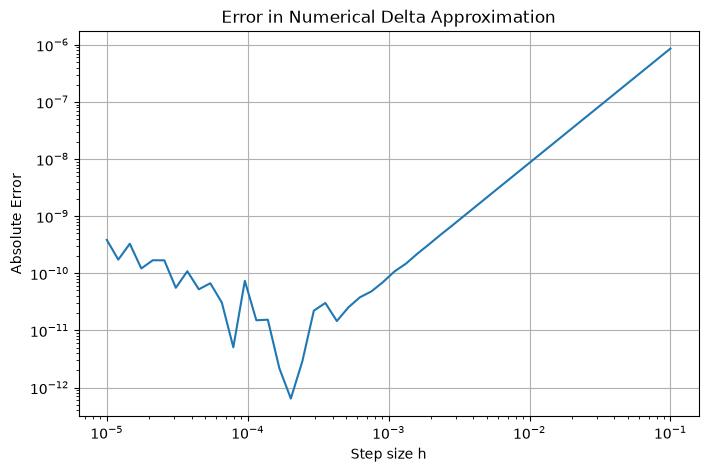

In [14]:
h_values = np.logspace(-5, -1, 50)
true_delta = delta_call(S, K, T, r, sigma)
delta_errors = [abs(numerical_delta(S, K, T, r, sigma, h=h) - true_delta) for h in h_values]

plt.figure(figsize=(8, 5))
plt.loglog(h_values, delta_errors)
plt.xlabel('Step size h'); plt.ylabel('Absolute Error'); plt.title('Error in Numerical Delta Approximation')
plt.grid(True); plt.show()

The choice of step size h matters: too large and truncation error dominates; too small and floating-point rounding error takes over. There's an optimal intermediate h where error is minimised — visible as the V-shape above.

Next: [03_monte_carlo_and_implied_vol.ipynb](03_monte_carlo_and_implied_vol.ipynb).